# Monte Carlo -- 8T bitcell hold SNM yield
Mismatch-only MC (`sw_stat_mismatch=1`, `sw_stat_global=0`) at a single fixed corner.
Local device-to-device mismatch is the dominant SNM killer in a bitcell; global process
is already pinned by the corner selection, so enabling it here would double-count.

NOTE: container/parsing helpers below are duplicated from pvt_sweep.ipynb.
If you change CONTAINER_NAME, CORNERS, or the parsing regexes -- change BOTH notebooks.


In [9]:
# %% -- paths + config
from pathlib import Path
import os, re, subprocess
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

HOST_WORKSPACE = Path.cwd().parent.parent.resolve()
ROOT    = HOST_WORKSPACE / "analog"
PVT     = ROOT / "designs" / "pvt.spice"
SIM8T   = ROOT / "sim" / "8t"
RESULTS = ROOT / "flow" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

CONTAINER_WORKSPACE = "/workspace/analog"
CONTAINER_NAME      = "chipathon-2026-iic"
GF180  = "/foss/pdks/gf180mcuD/libs.tech/ngspice"
LAUNCH_SCRIPT = HOST_WORKSPACE / "scripts" / "run_docker_iic.sh"

NUM = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"

# worst-SNM corner: slow devices, hot, low rail
MC_CORNER = dict(name="FS_125_2p97", lib="fs", temp=125, vdd=2.97)

N_CELLS = 4096      # array size -- sets the sigma bar
N_SIGMA = 5.0       # ~99.9% array yield at 4096 cells (see table below)

PVT_TEMPLATE = """* File: pvt.spice
* AUTO-GENERATED by monte_carlo.ipynb -- corner: {name}  (do not hand-edit during a run)
.include {gf180}/design.ngspice
.lib {gf180}/sm141064.ngspice {lib}
.temp {temp}
.param VDD_CORNER={vdd}
"""

# %% -- container
already_up = subprocess.run(
    ["docker", "ps", "-q", "--filter", f"name=^{CONTAINER_NAME}$"],
    capture_output=True, text=True, check=True,
).stdout.strip()

if not already_up:
    subprocess.run(["bash", str(LAUNCH_SCRIPT)],
                   env={**os.environ, "IIC_DETACH": "1"}, check=True)
print(f"CONTAINER: {CONTAINER_NAME}")

# %% -- helpers
def docker_exec(*args, cwd=None, **kwargs):
    """docker exec via login shell -- ngspice only lands on PATH via profile scripts."""
    da = ["docker", "exec"]
    if cwd:
        da += ["-w", cwd]
    da += [CONTAINER_NAME, "bash", "-lc", " ".join(args)]
    return subprocess.run(da, **kwargs)


def write_pvt(corner):
    PVT.write_text(PVT_TEMPLATE.format(gf180=GF180, **corner))


def to_container_path(path):
    return f"{CONTAINER_WORKSPACE}/{path.relative_to(ROOT).as_posix()}"


def run_ngspice(deck, timeout=300):
    return docker_exec("ngspice", "-b", to_container_path(deck), cwd=CONTAINER_WORKSPACE,
                       capture_output=True, text=True, timeout=timeout)


def had_error(proc):
    blob = proc.stdout + proc.stderr
    return proc.returncode != 0 or re.search(
        r"(?im)^\s*(fatal|undefined parameter|can't find|error on line|syntax error)", blob
    ) is not None


def meas_all(out, name):
    return [float(x) for x in re.findall(rf"^\s*{re.escape(name)}\s*=\s*({NUM})", out, re.M)]


CONTAINER: chipathon-2026-iic


## Run
`monte_carlo_hold.spice` defaults to nruns=1000. Smoke-test with a lower nruns in the deck before committing to a full run -- 1000 DC sweeps is not fast.

corner: FS_125_2p97   effective samples: 1000
Monte Carlo done: nruns=1000  skipped=0  effective_samples=1000
mu     = 0.8063 V
sigma  = 0.0103 V
mu - 5.0sigma = 0.7549 V  -> PASS
headroom: mu sits 78.4 sigma above zero SNM

NOTE: 1000 samples characterizes the distribution to ~3 sigma. The 5.0 sigma point is a Gaussian extrapolation, not a measured tail -- state it that way.


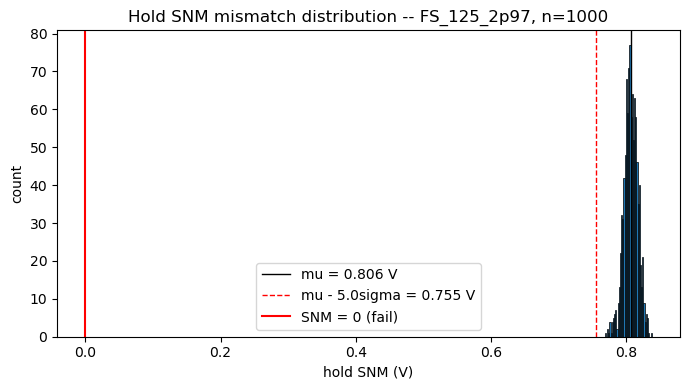

1000 samples -> /home/ratishgupta/vlsi/blueprints/analog/flow/results/mc_hold_snm.csv


In [10]:
original_pvt = PVT.read_text()
try:
    write_pvt(MC_CORNER)
    proc = run_ngspice(SIM8T / "monte_carlo_hold.spice", timeout=3600)
finally:
    PVT.write_text(original_pvt)      # always restore so git stays clean

if had_error(proc):
    print(f"[!] ngspice flagged an error (rc={proc.returncode}) -- inspect proc.stdout")

mc = np.array(meas_all(proc.stdout, "mc_snm"))
print(f"corner: {MC_CORNER['name']}   effective samples: {len(mc)}")

# ngspice prints its own skip/summary line -- surface it
for line in proc.stdout.splitlines():
    if "Monte Carlo done" in line:
        print(line.strip())

# -- stats + verdict
mu, sigma = mc.mean(), mc.std(ddof=1)

print(f"mu     = {mu:.4f} V")
print(f"sigma  = {sigma:.4f} V")
print(f"mu - {N_SIGMA}sigma = {mu - N_SIGMA*sigma:.4f} V  "
      f"-> {'PASS' if mu - N_SIGMA*sigma > 0 else 'FAIL'}")
print(f"headroom: mu sits {mu/sigma:.1f} sigma above zero SNM")
print(f"\nNOTE: {len(mc)} samples characterizes the distribution to ~3 sigma. The {N_SIGMA} "
      f"sigma point is a Gaussian extrapolation, not a measured tail -- state it that way.")

# -- distribution
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(mc, bins=40, edgecolor="black", linewidth=0.5)
ax.axvline(mu, color="k", lw=1, label=f"mu = {mu:.3f} V")
ax.axvline(mu - N_SIGMA*sigma, color="r", ls="--", lw=1,
           label=f"mu - {N_SIGMA}sigma = {mu - N_SIGMA*sigma:.3f} V")
ax.axvline(0, color="r", lw=1.5, label="SNM = 0 (fail)")
ax.set_xlabel("hold SNM (V)"); ax.set_ylabel("count")
ax.set_title(f"Hold SNM mismatch distribution -- {MC_CORNER['name']}, n={len(mc)}")
ax.legend()
plt.tight_layout(); plt.savefig(RESULTS / "mc_hold_snm.png", dpi=120); plt.show()

# -- save samples
np.savetxt(RESULTS / "mc_hold_snm.csv", mc, delimiter=",", header="hold_snm_V", comments="")
print(f"{len(mc)} samples -> {RESULTS/'mc_hold_snm.csv'}")


## Write margin -- Monte Carlo

Same mismatch-only MC, different metric. Unlike hold SNM (protected by the 8T's decoupled
read port), write margin is a direct strength fight between the access transistor and the
PMOS keeper -- mismatch hits it head-on, so this is where a yield limit would actually show.

CORNER: worst-`wlwm` corner measured in `pvt_sweep.csv` is **SS_m40_2p97** (wlwm=1.13695 V) --
NOT FF_m40_3p63, which is actually the *best* wlwm corner measured (1.58104 V). The
"strong keeper + weak access -> FF/SF" intuition doesn't hold here: this sweep's `ff`/`ss`
move NMOS and PMOS together, so there's no isolated "strong keeper, weak access" case among
the corners tested -- weak-everything (`ss`) comes out worst, strong-everything (`ff`) best.

NOTE: CORNERS currently lacks sf/fs (mixed) corners -- a genuine split corner (slow access +
fast keeper) isn't in `pvt_sweep.csv` at all and could still be worse than any matched corner
tested so far. This MC only proves out the worst *matched* corner available.


In [ ]:
WM_CORNER = dict(name="SF_125_2p97", lib="sf", temp=125, vdd=2.97)   # worst measured wlwm in pvt_sweep.csv (1.13695 V) -- see markdown above

original_pvt = PVT.read_text()
try:
    write_pvt(WM_CORNER)
    proc_wm = run_ngspice(SIM8T / "monte_carlo_wm.spice", timeout=3600)
finally:
    PVT.write_text(original_pvt)

if had_error(proc_wm):
    print(f"[!] ngspice flagged an error (rc={proc_wm.returncode}) -- inspect proc_wm.stdout")

wm = np.array(meas_all(proc_wm.stdout, "mc_wlwm"))
print(f"corner: {WM_CORNER['name']}   effective samples: {len(wm)}")

for line in proc_wm.stdout.splitlines():
    if "Monte Carlo done" in line:
        print(line.strip())      # includes solver= / endpoint= skip breakdown


corner: FS_125_2p97   effective samples: 1000
Monte Carlo done: nruns=1000  skipped=0 (solver=0 endpoint=0)  effective_samples=1000


In [17]:
mu_wm, sigma_wm = wm.mean(), wm.std(ddof=1)

print(f"mu     = {mu_wm:.4f} V")
print(f"sigma  = {sigma_wm:.4f} V")
print(f"mu - {N_SIGMA}sigma = {mu_wm - N_SIGMA*sigma_wm:.4f} V  "
      f"-> {'PASS' if mu_wm - N_SIGMA*sigma_wm > 0 else 'FAIL'}")
print(f"headroom: mu sits {mu_wm/sigma_wm:.1f} sigma above zero margin")
print(f"\nNOTE: {len(wm)} samples characterizes to ~3 sigma; the {N_SIGMA} sigma point is a "
      f"Gaussian extrapolation, not a measured tail.")


mu     = 1.4467 V
sigma  = 0.0243 V
mu - 5.0sigma = 1.3253 V  -> PASS
headroom: mu sits 59.6 sigma above zero margin

NOTE: 1000 samples characterizes to ~3 sigma; the 5.0 sigma point is a Gaussian extrapolation, not a measured tail.


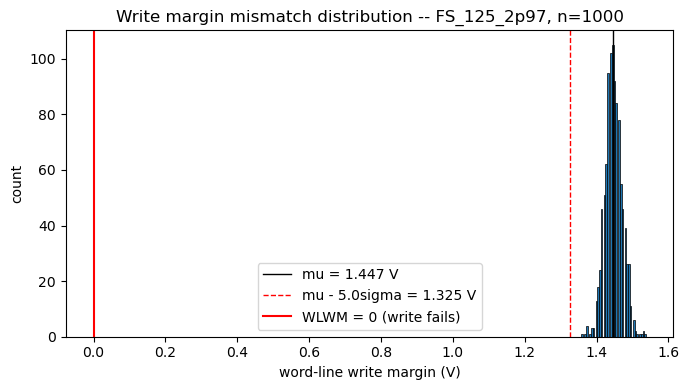

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(wm, bins=40, edgecolor="black", linewidth=0.5)
ax.axvline(mu_wm, color="k", lw=1, label=f"mu = {mu_wm:.3f} V")
ax.axvline(mu_wm - N_SIGMA*sigma_wm, color="r", ls="--", lw=1,
           label=f"mu - {N_SIGMA}sigma = {mu_wm - N_SIGMA*sigma_wm:.3f} V")
ax.axvline(0, color="r", lw=1.5, label="WLWM = 0 (write fails)")
ax.set_xlabel("word-line write margin (V)"); ax.set_ylabel("count")
ax.set_title(f"Write margin mismatch distribution -- {WM_CORNER['name']}, n={len(wm)}")
ax.legend()
plt.tight_layout(); plt.savefig(RESULTS / "mc_write_margin.png", dpi=120); plt.show()


In [19]:
np.savetxt(RESULTS / "mc_write_margin.csv", wm, delimiter=",",
           header="wlwm_V", comments="")
print(f"{len(wm)} samples -> {RESULTS/'mc_write_margin.csv'}")


1000 samples -> /home/ratishgupta/vlsi/blueprints/analog/flow/results/mc_write_margin.csv


In [20]:
print(f"{'metric':<16}{'corner':<16}{'mu':>10}{'sigma':>10}{f'mu-{N_SIGMA}s':>12}{'verdict':>10}")
for label, corner, m, s in [("hold_snm",  MC_CORNER["name"], mu,    sigma),
                            ("write_margin", WM_CORNER["name"], mu_wm, sigma_wm)]:
    floor = m - N_SIGMA*s
    print(f"{label:<16}{corner:<16}{m:>10.4f}{s:>10.4f}{floor:>12.4f}"
          f"{'PASS' if floor > 0 else 'FAIL':>10}")


metric          corner                  mu     sigma     mu-5.0s   verdict
hold_snm        FS_125_2p97         0.8063    0.0103      0.7549      PASS
write_margin    FS_125_2p97         1.4467    0.0243      1.3253      PASS
